# Analyse-data

L’objectif du notebook est d’analyser de manière rigoureuse et reproductible les performances des algorithmes PSO, GA et RANDOMSEARCH-5 sur les fonctions BBOB (f1, f8, f15, f20, f24) en dimension 20, à partir des fichiers .dat bruts issus de COCO. Il doit permettre de visualiser la convergence, agréger les runs, comparer les algorithmes et produire les figures/statistiques nécessaires au rapport scientifique et à la soutenance, conformément au protocole expérimental demandé par le séminaire.

## 1. Imports et paramètres globaux

In [3]:
import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import iqr, wilcoxon
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

ALGORITHMS = ["PSO", "RANDOMSEARCH-5", "GA"]
PROBLEMS = ["f1", "f8", "f15", "f20", "f24"]
DIMENSION = 20

BUDGET_LEVELS = {
    "petit": 100 * DIMENSION,
    "moyen": 1000 * DIMENSION,
    "grand": 10000 * DIMENSION
}

## 2. Configuration des chemins des fichiers

In [4]:
ROOT_DIR = Path('__file__').resolve().parent
DATA_DIRS = {
    "PSO": ROOT_DIR / "data_archive_pso",
    "RANDOMSEARCH-5": ROOT_DIR / "data_archive_RANDOMSEARCH-5",
    "GA": ROOT_DIR / "data_archive-GA",
}
FILE_PATTERNS = {
    "PSO": "bbobexp_{problem}_DIM20.dat",
    "RANDOMSEARCH-5": "bbobexp_{problem}_DIM20_i1.dat",
    "GA": "bbobexp_{problem}_DIM20.dat",
}

file_paths = {}
for algo, data_dir in DATA_DIRS.items():
    file_paths[algo] = {}
    for problem in PROBLEMS:
        filename = FILE_PATTERNS[algo].format(problem=problem)
        path = data_dir / filename
        file_paths[algo][problem] = str(path)
        if not path.exists():
            warnings.warn(
                f"Fichier introuvable pour {algo} {problem} : {path}",
                UserWarning,
            )

## 3. Vérification des chemins
Analyse et validation des chemins d'accès aux fichiers `.dat` avant le traitement.

In [5]:
def validate_file_paths(file_paths):
    errors = []
    for algo, problem_dict in file_paths.items():
        for problem, path in problem_dict.items():
            if "INSERER_ICI" in path:
                errors.append(f"[A REMPLIR] {algo} - {problem} : chemin non renseigné")
            elif not Path(path).exists():
                errors.append(f"[INTROUVABLE] {algo} - {problem} : {path}")
    return errors

errors = validate_file_paths(file_paths)

if errors:
    print("Des problèmes ont été détectés :")
    for err in errors:
        print(" -", err)
else:
    print("Tous les chemins semblent valides.")

Tous les chemins semblent valides.


## 4. Parsing des fichiers `.dat` BBOB
Fonctions de lecture et de conversion des fichiers bruts en jeux de données structurés.

In [6]:
# ============================================================
# 4. PARSING DES FICHIERS .dat BBOB
# ============================================================

def is_numeric_line(line: str) -> bool:
    """
    Détermine si une ligne contient des données numériques exploitables.
    Les lignes de commentaires BBOB commencent souvent par '%'.
    """
    line = line.strip()
    if not line:
        return False
    if line.startswith("%"):
        return False
    
    # on teste si le premier token peut être lu comme un nombre
    first_token = line.split()[0]
    try:
        float(first_token)
        return True
    except ValueError:
        return False


def parse_run_header_metadata(line: str) -> dict:
    """
    Essaie d'extraire des métadonnées depuis une ligne de commentaire/en-tête.
    On reste volontairement robuste car le format peut varier selon les archives.
    """
    meta = {}
    
    # instance
    m_instance = re.search(r"instance\s*[:=]?\s*(\d+)", line, flags=re.IGNORECASE)
    if m_instance:
        meta["instance"] = int(m_instance.group(1))
    
    # fonction
    m_func = re.search(r"f(\d+)", line, flags=re.IGNORECASE)
    if m_func:
        meta["function"] = f"f{m_func.group(1)}"
    
    # dimension
    m_dim = re.search(r"(?:DIM|dim|dimension)\s*[:=]?\s*(\d+)", line)
    if m_dim:
        meta["dimension"] = int(m_dim.group(1))
    
    return meta


def parse_bbob_dat_file(filepath: str, algorithm: str, problem: str, expected_dimension: int = 20):
    """
    Parse un fichier .dat BBOB brut et retourne :
    - un DataFrame concaténé de tous les points
    - un DataFrame résumé par run
    
    Hypothèse standard sur les colonnes :
    1 = evaluations
    2 = noise-free fitness - Fopt
    3 = best noise-free fitness - Fopt
    4 = measured fitness
    5 = best measured fitness
    6... = x1, x2, ...
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Fichier introuvable : {filepath}")

    runs = []
    current_run_data = []
    current_meta = {
        "algorithm": algorithm,
        "problem": problem,
        "dimension": expected_dimension,
        "instance": None,
        "run_id": None
    }
    run_counter = 0

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for line in lines:
        stripped = line.strip()

        # Ligne commentaire / méta
        if stripped.startswith("%"):
            meta_update = parse_run_header_metadata(stripped)
            current_meta.update({k: v for k, v in meta_update.items() if v is not None})
            continue

        # Ligne numérique
        if is_numeric_line(stripped):
            parts = stripped.split()
            values = []
            for p in parts:
                try:
                    values.append(float(p))
                except ValueError:
                    values.append(np.nan)
            current_run_data.append(values)
        else:
            # Si on rencontre une ligne non numérique après avoir accumulé des données,
            # on clôt le run courant
            if current_run_data:
                run_counter += 1
                run_df = build_run_dataframe(
                    current_run_data,
                    algorithm=algorithm,
                    problem=problem,
                    dimension=current_meta.get("dimension", expected_dimension),
                    instance=current_meta.get("instance"),
                    run_id=run_counter
                )
                runs.append(run_df)
                current_run_data = []

    # dernier run
    if current_run_data:
        run_counter += 1
        run_df = build_run_dataframe(
            current_run_data,
            algorithm=algorithm,
            problem=problem,
            dimension=current_meta.get("dimension", expected_dimension),
            instance=current_meta.get("instance"),
            run_id=run_counter
        )
        runs.append(run_df)

    if not runs:
        raise ValueError(f"Aucun run numérique détecté dans le fichier : {filepath}")

    all_points = pd.concat(runs, ignore_index=True)

    # résumé par run
    summary_rows = []
    for run_id, g in all_points.groupby("run_id"):
        g = g.sort_values("evaluations")
        summary_rows.append({
            "algorithm": algorithm,
            "problem": problem,
            "dimension": int(g["dimension"].iloc[0]),
            "run_id": int(run_id),
            "instance": g["instance"].iloc[0] if "instance" in g.columns else np.nan,
            "n_points": len(g),
            "eval_min": g["evaluations"].min(),
            "eval_max": g["evaluations"].max(),
            "final_delta_f": g["best_noise_free_fitness_minus_Fopt"].iloc[-1],
            "best_delta_f": g["best_noise_free_fitness_minus_Fopt"].min(),
        })

    runs_summary = pd.DataFrame(summary_rows)
    return all_points, runs_summary


def build_run_dataframe(run_data, algorithm, problem, dimension, instance, run_id):
    """
    Construit le DataFrame d'un run à partir d'une matrice numérique.
    """
    max_len = max(len(row) for row in run_data)

    column_names = [
        "evaluations",
        "noise_free_fitness_minus_Fopt",
        "best_noise_free_fitness_minus_Fopt",
        "measured_fitness",
        "best_measured_fitness"
    ]

    if max_len > 5:
        x_cols = [f"x{i}" for i in range(1, max_len - 5 + 1)]
        column_names = column_names + x_cols

    padded_data = []
    for row in run_data:
        padded_row = row + [np.nan] * (max_len - len(row))
        padded_data.append(padded_row)

    df = pd.DataFrame(padded_data, columns=column_names)

    df["algorithm"] = algorithm
    df["problem"] = problem
    df["dimension"] = dimension
    df["instance"] = instance if instance is not None else np.nan
    df["run_id"] = run_id

    # nettoyage minimum
    df = df.sort_values("evaluations").reset_index(drop=True)

    # sécurité numérique pour log-scale
    for col in [
        "noise_free_fitness_minus_Fopt",
        "best_noise_free_fitness_minus_Fopt",
        "measured_fitness",
        "best_measured_fitness"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

## 5. Chargement de tous les fichiers
Chargement des fichiers `.dat` pour chaque algorithme et chaque problème, et concaténation des résultats.
## Cellule 5
chargement global

In [7]:
# ============================================================
# 5. CHARGEMENT DE TOUS LES FICHIERS
# ============================================================

all_points_list = []
all_runs_summary_list = []

for algo in ALGORITHMS:
    for problem in PROBLEMS:
        path = file_paths[algo][problem]
        points_df, runs_summary_df = parse_bbob_dat_file(
            filepath=path,
            algorithm=algo,
            problem=problem,
            expected_dimension=DIMENSION
        )
        all_points_list.append(points_df)
        all_runs_summary_list.append(runs_summary_df)

all_points = pd.concat(all_points_list, ignore_index=True)
all_runs_summary = pd.concat(all_runs_summary_list, ignore_index=True)

print("Chargement terminé.")
print("all_points shape :", all_points.shape)
print("all_runs_summary shape :", all_runs_summary.shape)

display(all_runs_summary.head())

Chargement terminé.
all_points shape : (4646, 30)
all_runs_summary shape : (15, 10)


,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,752,1.0,26565.0,9.791108e-09,6.651248e-09
1,PSO,f8,20,1,NaN,703,1.0,1990901.0,1.584650e-06,9.998558e-09
2,PSO,f15,20,1,NaN,137,1.0,36907.0,6.307841e+01,2.501948e+01
3,PSO,f20,20,1,NaN,266,1.0,52703.0,9.995077e-01,6.257751e-01
4,PSO,f24,20,1,NaN,101,1.0,1095292.0,9.952067e+01,2.510353e+01


## Cellule 6. Vérifications de cohérence
Contrôles préliminaires pour s'assurer que les données importées sont complètes et cohérentes.

In [8]:
# ============================================================
# 6. VERIFICATIONS DE COHERENCE
# ============================================================

print("Algorithmes détectés :", sorted(all_points["algorithm"].unique()))
print("Problèmes détectés   :", sorted(all_points["problem"].unique()))
print("Dimensions détectées :", sorted(all_points["dimension"].dropna().unique()))

print("\nNombre de runs par algorithme et problème :")
display(
    all_runs_summary.groupby(["algorithm", "problem"])["run_id"]
    .nunique()
    .unstack(fill_value=0)
)

print("\nRésumé des évaluations max par algorithme et problème :")
display(
    all_runs_summary.groupby(["algorithm", "problem"])["eval_max"]
    .agg(["min", "median", "max"])
)

Algorithmes détectés : ['GA', 'PSO', 'RANDOMSEARCH-5']
Problèmes détectés   : ['f1', 'f15', 'f20', 'f24', 'f8']
Dimensions détectées : [np.int64(20)]

Nombre de runs par algorithme et problème :


problem,f1,f15,f20,f24,f8
algorithm,,,,,
GA,1,1,1,1,1
PSO,1,1,1,1,1
RANDOMSEARCH-5,1,1,1,1,1



Résumé des évaluations max par algorithme et problème :


min       median          max
algorithm      problem                                       
GA             f1          922819.0     922819.0     922819.0
               f15        1061221.0    1061221.0    1061221.0
               f20        1540718.0    1540718.0    1540718.0
               f24         560956.0     560956.0     560956.0
               f8          352848.0     352848.0     352848.0
PSO            f1           26565.0      26565.0      26565.0
               f15          36907.0      36907.0      36907.0
               f20          52703.0      52703.0      52703.0
               f24        1095292.0    1095292.0    1095292.0
               f8         1990901.0    1990901.0    1990901.0
RANDOMSEARCH-5 f1       194967389.0  194967389.0  194967389.0
               f15      188500985.0  188500985.0  188500985.0
               f20      198080193.0  198080193.0  198080193.0
               f24      195538622.0  195538622.0  195538622.0
               f8       198208380.0  198208380.0  198208380.0

## 6. Fonctions utilitaires pour l’analyse scientifique

## Cellule 7. Fonctions d'agrégation des courbes de convergence
Définitions des fonctions permettant d'agréger et d'interpoler les courbes de convergence entre runs.

In [9]:
# ============================================================
# 7. FONCTIONS D'AGREGATION DES COURBES DE CONVERGENCE
# ============================================================

def get_subset(points_df, algorithm=None, problem=None):
    df = points_df.copy()
    if algorithm is not None:
        df = df[df["algorithm"] == algorithm]
    if problem is not None:
        df = df[df["problem"] == problem]
    return df


def build_common_eval_grid(df_subset, n_points=200):
    """
    Grille logarithmique commune pour agréger les runs.
    """
    eval_min = max(1, df_subset["evaluations"].min())
    eval_max = df_subset["evaluations"].max()
    return np.unique(np.logspace(np.log10(eval_min), np.log10(eval_max), n_points).astype(int))


def interpolate_run_on_grid(run_df, grid, y_col="best_noise_free_fitness_minus_Fopt"):
    """
    Interpole la courbe d'un run sur une grille commune.
    On utilise une interpolation 'previous' logique pour des courbes anytime.
    """
    run_df = run_df.sort_values("evaluations")
    x = run_df["evaluations"].values
    y = run_df[y_col].values

    # nettoyer les NaN
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return np.full(len(grid), np.nan)

    # rendre x strictement croissants si doublons
    x_unique, idx = np.unique(x, return_index=True)
    y_unique = y[idx]

    # interpolation en mode "step"
    result = np.empty(len(grid), dtype=float)
    j = 0
    current_y = y_unique[0]

    for i, gx in enumerate(grid):
        while j + 1 < len(x_unique) and x_unique[j + 1] <= gx:
            j += 1
            current_y = y_unique[j]
        result[i] = current_y

    return result


def aggregate_convergence(points_df, algorithm, problem, y_col="best_noise_free_fitness_minus_Fopt", n_grid=200):
    """
    Retourne une table agrégée des courbes de convergence pour un algo et un problème.
    """
    subset = get_subset(points_df, algorithm=algorithm, problem=problem)
    grid = build_common_eval_grid(subset, n_points=n_grid)

    curves = []
    run_ids = []

    for run_id, run_df in subset.groupby("run_id"):
        curve = interpolate_run_on_grid(run_df, grid, y_col=y_col)
        curves.append(curve)
        run_ids.append(run_id)

    curves = np.array(curves)

    agg_df = pd.DataFrame({
        "evaluations": grid,
        "mean": np.nanmean(curves, axis=0),
        "median": np.nanmedian(curves, axis=0),
        "q25": np.nanpercentile(curves, 25, axis=0),
        "q75": np.nanpercentile(curves, 75, axis=0),
        "min": np.nanmin(curves, axis=0),
        "max": np.nanmax(curves, axis=0),
    })

    return agg_df, curves, run_ids

## 7. Étape 1 -Analyse détaillée d’un algorithme sur un problème
Je prends ici un exemple : PSO sur f1. 


## Cellule 8 — Paramètres du cas d’étude

In [ ]:
# ============================================================
# 8. ETAPE 1 - CAS D'ETUDE
# ============================================================

CASE_ALGO = "PSO"
CASE_PROBLEM = "f1"

case_points = get_subset(all_points, algorithm=CASE_ALGO, problem=CASE_PROBLEM)
case_runs = all_runs_summary[
    (all_runs_summary["algorithm"] == CASE_ALGO) &
    (all_runs_summary["problem"] == CASE_PROBLEM)
].copy()

print(f"Cas d'étude : {CASE_ALGO} sur {CASE_PROBLEM}")
print(f"Nombre de runs : {case_runs['run_id'].nunique()}")
display(case_runs.head())

Cas d'étude : PSO sur f1
Nombre de runs : 1


,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,752,1.0,26565.0,9.791108e-09,6.651248e-09


## Cellule 9. Analyse d'un run unique
Analyse détaillée d'une courbe de convergence pour un seul run, avec interprétation visuelle.

## Cellule 10. Analyse multi-runs
Superposition des courbes de convergence de tous les runs pour évaluer la robustesse et la variabilité de l'algorithme.

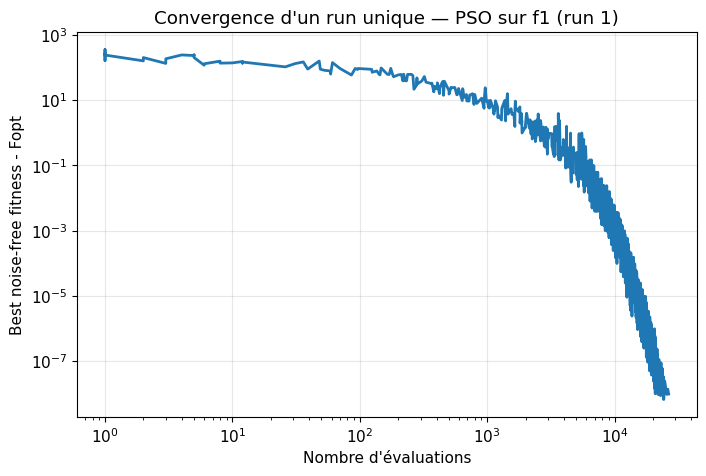

,evaluations,noise_free_fitness_minus_Fopt,best_noise_free_fitness_minus_Fopt,measured_fitness,best_measured_fitness,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,algorithm,problem,dimension,instance,run_id
0,1.0,258.190779,258.190779,337.670779,337.670779,-0.94502,-0.3254,-0.98204,2.12050,4.99450,-2.38030,-2.3685,-0.61365,-0.694620,3.949700,-1.3194,0.48215,-2.62760,3.7297,-3.04060,-2.52800,2.46190,-3.7561,-1.2205,2.97580,PSO,f1,20,NaN,1
14,1.0,191.104427,191.104427,-56.005573,-56.005573,-4.11170,1.4847,2.37170,2.70440,-0.29201,0.53827,3.4225,-4.66890,0.961530,-0.004499,2.4446,2.65480,-3.19760,-3.6100,4.08760,-0.68489,-1.53200,3.8804,4.9148,4.17980,PSO,f1,20,NaN,1
13,1.0,203.707013,203.707013,51.667013,51.667013,2.08040,-3.6850,-3.85120,-0.69768,1.96560,3.40640,-1.1136,-2.22800,0.770170,4.519400,2.4195,3.98440,-2.74520,-3.7178,0.66583,-0.94812,3.68410,-3.6491,-0.9708,1.96660,PSO,f1,20,NaN,1
12,1.0,305.110731,305.110731,279.860731,279.860731,0.99923,-4.9581,1.14380,-3.40410,-2.89740,3.16890,2.1470,3.92910,-0.088234,3.097600,4.8156,3.14420,-0.78733,3.5790,0.11755,-4.05430,3.13020,1.9271,4.6996,4.26910,PSO,f1,20,NaN,1
11,1.0,332.709067,332.709067,727.189067,727.189067,1.06240,3.5852,-0.11980,1.95030,-1.63590,3.65840,-3.4050,3.85280,-3.695800,-1.975500,2.3137,-2.82560,-1.08260,-1.6715,1.99780,3.88380,0.60221,2.3266,2.6535,0.34485,PSO,f1,20,NaN,1


,evaluations,noise_free_fitness_minus_Fopt,best_noise_free_fitness_minus_Fopt,measured_fitness,best_measured_fitness,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,algorithm,problem,dimension,instance,run_id
747,24743.0,2.437184e-08,2.437184e-08,394.48,394.48,-3.89840,-2.8904,-3.8025,3.9056,0.85924,-2.90480,3.44480,-0.59997,-0.88235,-3.7352,1.90950,1.2704,1.5712,3.7712,-3.81600,2.9601,-2.8976,-1.39280,0.10403,1.2824,PSO,f1,20,NaN,1
748,25167.0,1.531868e-08,1.531868e-08,-152.04,-152.04,-0.26716,1.4240,-3.9248,3.2968,2.41920,0.15037,-0.87846,-0.70078,1.50000,3.4808,-0.84401,-2.6416,-3.9088,3.8936,0.28401,1.2369,2.0504,0.29919,-0.36397,3.9512,PSO,f1,20,NaN,1
749,25623.0,9.601393e-09,9.601393e-09,-152.04,-152.04,-0.26721,1.4240,-3.9248,3.2968,2.41920,0.15039,-0.87841,-0.70083,1.50000,3.4808,-0.84400,-2.6416,-3.9088,3.8936,0.28402,1.2368,2.0504,0.29920,-0.36398,3.9512,PSO,f1,20,NaN,1
750,26150.0,1.385303e-08,1.385303e-08,394.48,394.48,-3.89840,-2.8904,-3.8024,3.9056,0.85920,-2.90480,3.44480,-0.59998,-0.88237,-3.7352,1.90950,1.2704,1.5712,3.7712,-3.81600,2.9600,-2.8976,-1.39280,0.10403,1.2824,PSO,f1,20,NaN,1
751,26565.0,9.791108e-09,9.791108e-09,394.48,394.48,-3.89840,-2.8904,-3.8024,3.9056,0.85919,-2.90480,3.44480,-0.59998,-0.88238,-3.7352,1.90950,1.2704,1.5712,3.7712,-3.81600,2.9600,-2.8976,-1.39280,0.10404,1.2824,PSO,f1,20,NaN,1


In [11]:
# ============================================================
# 9. ANALYSE D'UN RUN UNIQUE
# ============================================================

chosen_run_id = case_runs.sort_values("final_delta_f")["run_id"].iloc[0]  # meilleur run final
single_run = case_points[case_points["run_id"] == chosen_run_id].sort_values("evaluations")

plt.figure(figsize=(8, 5))
plt.plot(single_run["evaluations"], single_run["best_noise_free_fitness_minus_Fopt"], linewidth=2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Convergence d'un run unique — {CASE_ALGO} sur {CASE_PROBLEM} (run {chosen_run_id})")
plt.show()

display(single_run.head())
display(single_run.tail())

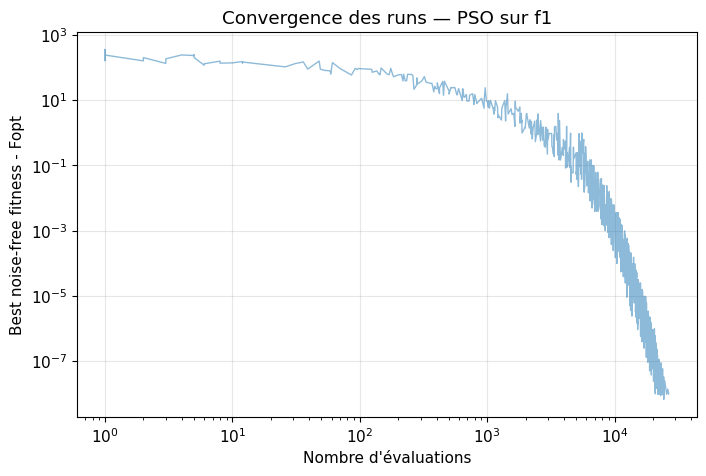

In [12]:
# ============================================================
# 10. ANALYSE MULTI-RUNS
# ============================================================

plt.figure(figsize=(8, 5))
for run_id, run_df in case_points.groupby("run_id"):
    run_df = run_df.sort_values("evaluations")
    plt.plot(
        run_df["evaluations"],
        run_df["best_noise_free_fitness_minus_Fopt"],
        alpha=0.5,
        linewidth=1
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Convergence des runs — {CASE_ALGO} sur {CASE_PROBLEM}")
plt.show()

La superposition des runs permet d'évaluer la robustesse de l'algorithme. Des courbes proches indiquent une faible sensibilité à l'aléa, alors qu'une forte dispersion traduit un comportement stochastique important et une fiabilité plus faible sur ce problème.

## 11. Agrégation des runs : moyenne, médiane, IQR
Construction d'une courbe agrégée montrant la tendance centrale (moyenne et médiane) et la dispersion (intervalle interquartile) des performances.

## 12. Statistiques descriptives finales
Synthèse des métriques résumées : moyenne, médiane, écart-type, IQR et coefficient de variation pour le cas étudié.

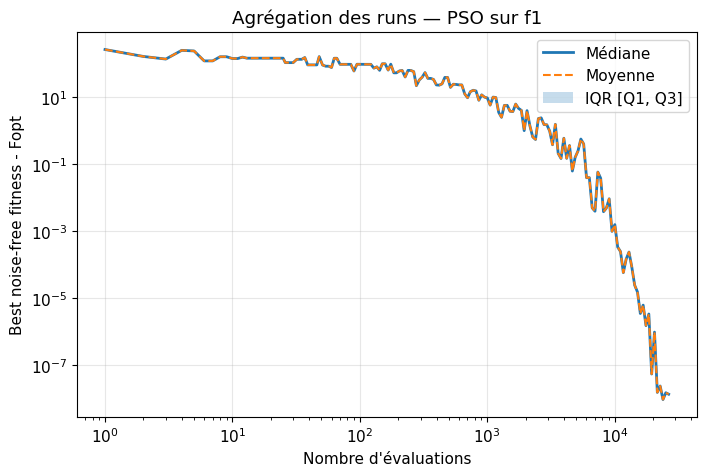

In [13]:
# ============================================================
# 11. AGREGER LES RUNS : MOYENNE, MEDIANE, IQR
# ============================================================

agg_case, curves_case, run_ids_case = aggregate_convergence(
    all_points,
    algorithm=CASE_ALGO,
    problem=CASE_PROBLEM
)

plt.figure(figsize=(8, 5))
plt.plot(agg_case["evaluations"], agg_case["median"], label="Médiane", linewidth=2)
plt.plot(agg_case["evaluations"], agg_case["mean"], label="Moyenne", linestyle="--")
plt.fill_between(
    agg_case["evaluations"],
    agg_case["q25"],
    agg_case["q75"],
    alpha=0.25,
    label="IQR [Q1, Q3]"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Agrégation des runs — {CASE_ALGO} sur {CASE_PROBLEM}")
plt.legend()
plt.show()

In [14]:
# ============================================================
# 12. STATISTIQUES DESCRIPTIVES FINALES
# ============================================================

case_stats = case_runs["final_delta_f"].agg(["mean", "median", "min", "max", "std"]).to_frame().T
case_stats["iqr"] = iqr(case_runs["final_delta_f"].dropna())
case_stats["cv"] = case_stats["std"] / case_stats["mean"]

display(case_stats)

,mean,median,min,max,std,iqr,cv
final_delta_f,9.791108e-09,9.791108e-09,9.791108e-09,9.791108e-09,NaN,0.0,NaN


La médiane constitue ici un indicateur central robuste, particulièrement pertinent en présence de distributions asymétriques ou de runs atypiques. L'IQR complète cette lecture en mesurant la dispersion interquartile. Une moyenne proche de la médiane et un IQR faible suggèrent une bonne stabilité de l'algorithme sur le problème considéré.

## 13. ETAPE 2 - UN ALGORITHME SUR PLUSIEURS PROBLEMES
choix de l'algo


## Cellule 14 — Boxplots des performances finales par problème

In [15]:
# ============================================================
# 13. ETAPE 2 - UN ALGORITHME SUR PLUSIEURS PROBLEMES
# ============================================================

ALGO_MULTI = "PSO"

multi_runs = all_runs_summary[all_runs_summary["algorithm"] == ALGO_MULTI].copy()
multi_points = all_points[all_points["algorithm"] == ALGO_MULTI].copy()

display(multi_runs.head())

,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,752,1.0,26565.0,9.791108e-09,6.651248e-09
1,PSO,f8,20,1,NaN,703,1.0,1990901.0,1.584650e-06,9.998558e-09
2,PSO,f15,20,1,NaN,137,1.0,36907.0,6.307841e+01,2.501948e+01
3,PSO,f20,20,1,NaN,266,1.0,52703.0,9.995077e-01,6.257751e-01
4,PSO,f24,20,1,NaN,101,1.0,1095292.0,9.952067e+01,2.510353e+01


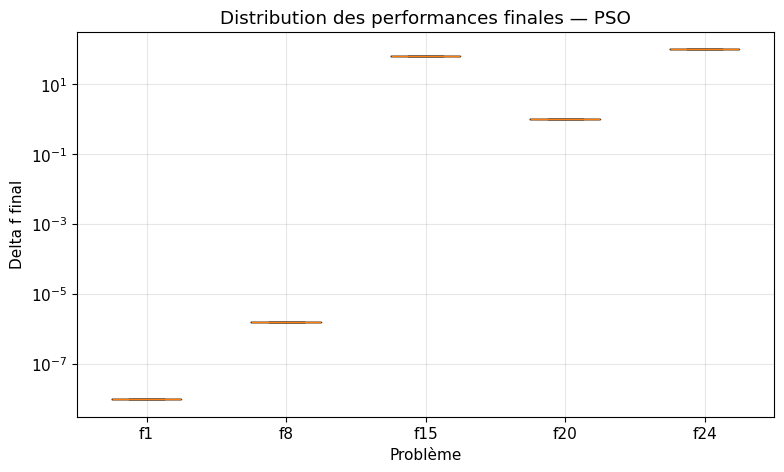

In [16]:
# ============================================================
# 14. BOXPLOTS PAR PROBLEME
# ============================================================

data_for_boxplot = [
    multi_runs[multi_runs["problem"] == pb]["final_delta_f"].dropna().values
    for pb in PROBLEMS
]

plt.figure(figsize=(9, 5))
plt.boxplot(data_for_boxplot, tick_labels=PROBLEMS)
plt.yscale("log")
plt.xlabel("Problème")
plt.ylabel("Delta f final")
plt.title(f"Distribution des performances finales — {ALGO_MULTI}")
plt.show()

## Cellule 15 — Courbes médianes par problème

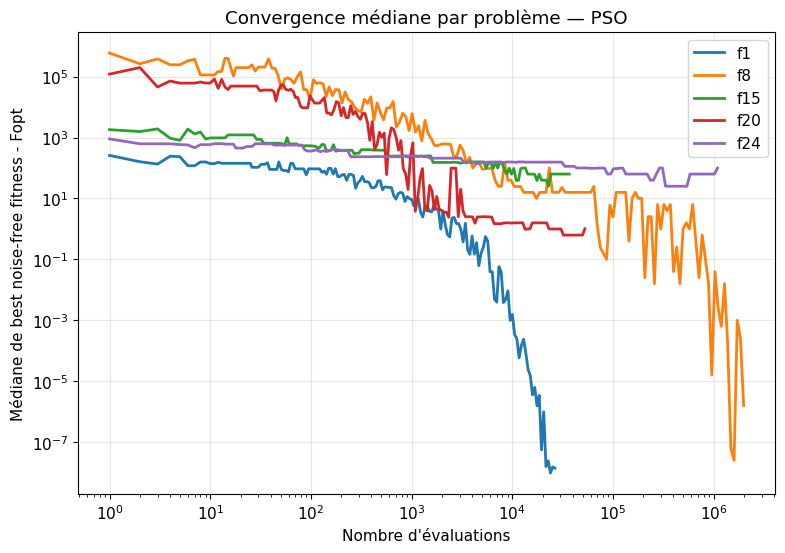

In [17]:
# ============================================================
# 15. COURBES DE CONVERGENCE MEDIANES PAR PROBLEME
# ============================================================

plt.figure(figsize=(9, 6))

for pb in PROBLEMS:
    agg_df, _, _ = aggregate_convergence(all_points, algorithm=ALGO_MULTI, problem=pb)
    plt.plot(agg_df["evaluations"], agg_df["median"], label=pb, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Médiane de best noise-free fitness - Fopt")
plt.title(f"Convergence médiane par problème — {ALGO_MULTI}")
plt.legend()
plt.show()

## Cellule 16 — Heatmap des performances finales

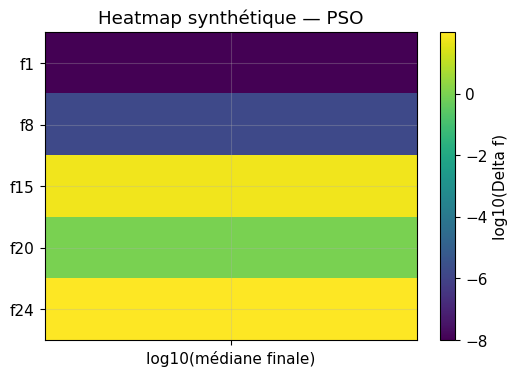

,median_final_delta_f,log10_median
problem,,
f1,9.791108e-09,-8.009168
f8,1.584650e-06,-5.800067
f15,6.307841e+01,1.799881
f20,9.995077e-01,-0.000214
f24,9.952067e+01,1.997913


In [18]:
# ============================================================
# 16. HEATMAP DES PERFORMANCES FINALES
# ============================================================

heatmap_df = (
    multi_runs.groupby(["problem"])["final_delta_f"]
    .median()
    .reindex(PROBLEMS)
    .to_frame(name="median_final_delta_f")
)

heatmap_df["log10_median"] = np.log10(np.clip(heatmap_df["median_final_delta_f"], 1e-300, None))

plt.figure(figsize=(6, 4))
plt.imshow(heatmap_df[["log10_median"]].values, aspect="auto")
plt.yticks(range(len(PROBLEMS)), PROBLEMS)
plt.xticks([0], ["log10(médiane finale)"])
plt.colorbar(label="log10(Delta f)")
plt.title(f"Heatmap synthétique — {ALGO_MULTI}")
plt.show()

display(heatmap_df)

## Cellule 17 — ECDF par problème

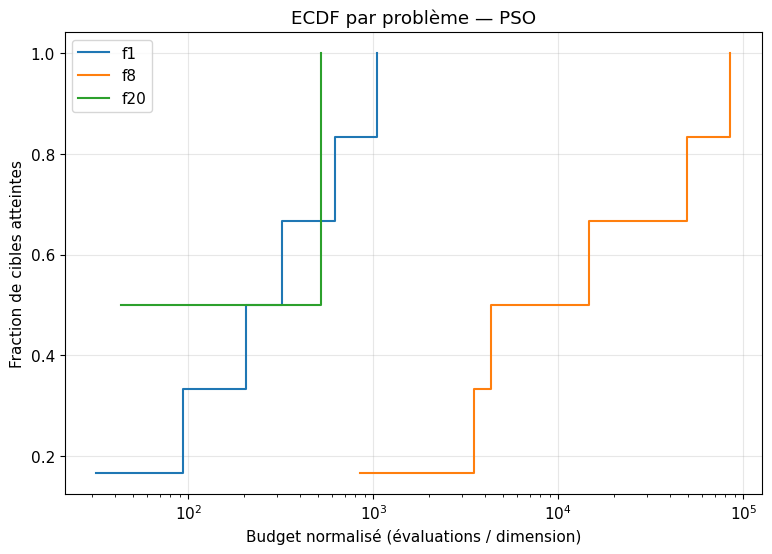

In [19]:
# ============================================================
# 17. ECDF PAR PROBLEME
# ============================================================

TARGETS = [1e1, 1e0, 1e-1, 1e-2, 1e-5, 1e-8]

def first_hitting_time(run_df, target, y_col="best_noise_free_fitness_minus_Fopt"):
    run_df = run_df.sort_values("evaluations")
    reached = run_df[run_df[y_col] <= target]
    if len(reached) == 0:
        return np.nan
    return reached["evaluations"].iloc[0]

def ecdf_curve_for_algo_problem(points_df, algorithm, problem, targets=TARGETS):
    subset = get_subset(points_df, algorithm=algorithm, problem=problem)
    times = []

    for run_id, run_df in subset.groupby("run_id"):
        for target in targets:
            t = first_hitting_time(run_df, target=target)
            if not np.isnan(t):
                times.append(t / DIMENSION)  # budget normalisé par la dimension

    if len(times) == 0:
        return np.array([]), np.array([])

    times = np.sort(np.array(times))
    y = np.arange(1, len(times) + 1) / len(times)
    return times, y

plt.figure(figsize=(9, 6))

for pb in PROBLEMS:
    x_ecdf, y_ecdf = ecdf_curve_for_algo_problem(all_points, ALGO_MULTI, pb)
    if len(x_ecdf) > 0:
        plt.step(x_ecdf, y_ecdf, where="post", label=pb)

plt.xscale("log")
plt.xlabel("Budget normalisé (évaluations / dimension)")
plt.ylabel("Fraction de cibles atteintes")
plt.title(f"ECDF par problème — {ALGO_MULTI}")
plt.legend()
plt.show()

L’ECDF permet une synthèse globale de la capacité d’un algorithme à atteindre différentes cibles de précision sous des budgets variés. Une courbe plus haute et plus à gauche indique un algorithme plus efficace : il atteint une plus grande fraction de cibles avec moins d’évaluations.

## 9. Étape 3 — Comparaison des 3 algorithmes
## Cellule 18 — Boxplots comparatifs sur un problème


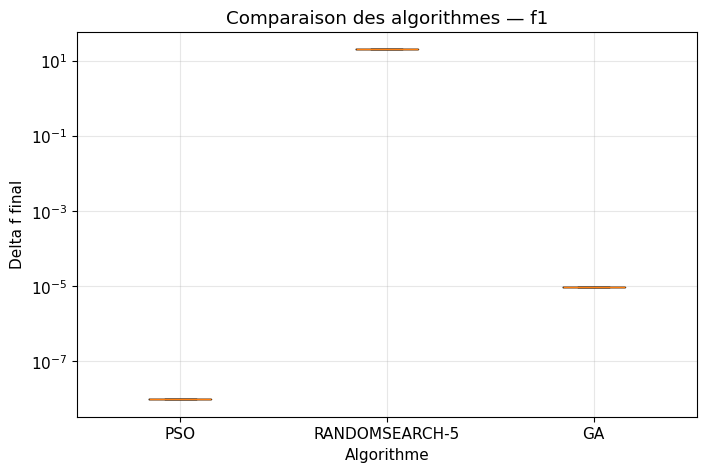

In [20]:
# ============================================================
# 18. COMPARAISON DES 3 ALGORITHMES SUR UN PROBLEME
# ============================================================

COMPARE_PROBLEM = "f1"

compare_df = all_runs_summary[all_runs_summary["problem"] == COMPARE_PROBLEM].copy()

data_for_boxplot = [
    compare_df[compare_df["algorithm"] == algo]["final_delta_f"].dropna().values
    for algo in ALGORITHMS
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_for_boxplot, tick_labels=ALGORITHMS)
plt.yscale("log")
plt.xlabel("Algorithme")
plt.ylabel("Delta f final")
plt.title(f"Comparaison des algorithmes — {COMPARE_PROBLEM}")
plt.show()

## Cellule 19 — Courbes médianes comparatives

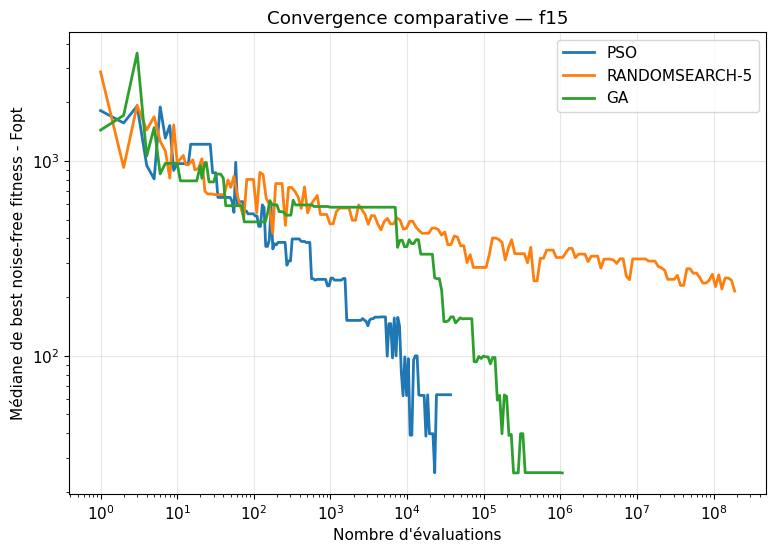

In [21]:
# ============================================================
# 19. COURBES DE CONVERGENCE COMPARATIVES
# ============================================================

COMPARE_PROBLEM = "f15"

plt.figure(figsize=(9, 6))

for algo in ALGORITHMS:
    agg_df, _, _ = aggregate_convergence(all_points, algorithm=algo, problem=COMPARE_PROBLEM)
    plt.plot(agg_df["evaluations"], agg_df["median"], label=algo, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Médiane de best noise-free fitness - Fopt")
plt.title(f"Convergence comparative — {COMPARE_PROBLEM}")
plt.legend()
plt.show()

## Cellule 20 — Heatmap algorithmes × problèmes

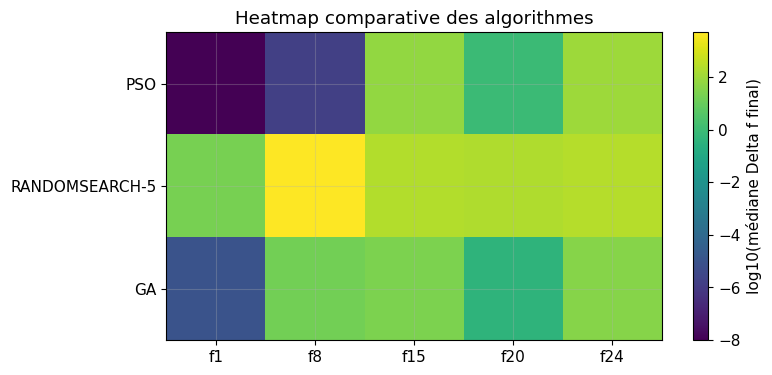

problem,f1,f8,f15,f20,f24
algorithm,,,,,
PSO,9.791108e-09,0.000002,63.078407,0.999508,99.520673
RANDOMSEARCH-5,2.038579e+01,5183.490843,228.707719,200.450534,245.320230
GA,9.361856e-06,15.832685,25.016707,0.394628,39.745621


In [22]:
# ============================================================
# 20. HEATMAP ALGORITHMES x PROBLEMES
# ============================================================

perf_table = (
    all_runs_summary.groupby(["algorithm", "problem"])["final_delta_f"]
    .median()
    .unstack()
    .reindex(index=ALGORITHMS, columns=PROBLEMS)
)

perf_table_log = np.log10(np.clip(perf_table, 1e-300, None))

plt.figure(figsize=(8, 4))
plt.imshow(perf_table_log.values, aspect="auto")
plt.xticks(range(len(PROBLEMS)), PROBLEMS)
plt.yticks(range(len(ALGORITHMS)), ALGORITHMS)
plt.colorbar(label="log10(médiane Delta f final)")
plt.title("Heatmap comparative des algorithmes")
plt.show()

display(perf_table)

## Cellule 21 — Meilleur algorithme par problème

In [23]:
# ============================================================
# 21. MEILLEUR ALGORITHME PAR PROBLEME
# ============================================================

best_algo_by_problem = perf_table.idxmin(axis=0).to_frame(name="best_algorithm")
best_algo_by_problem["best_value"] = perf_table.min(axis=0).values

display(best_algo_by_problem)

,best_algorithm,best_value
problem,,
f1,PSO,9.791108e-09
f8,PSO,1.584650e-06
f15,GA,2.501671e+01
f20,GA,3.946279e-01
f24,GA,3.974562e+01


## Cellule 22 — ECDF globale comparative

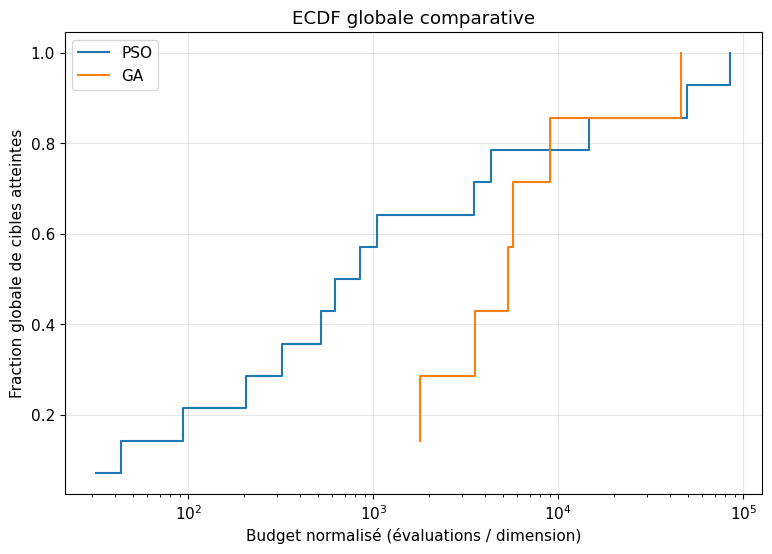

In [24]:
# ============================================================
# 22. ECDF GLOBALE COMPARATIVE
# ============================================================

def ecdf_curve_global(points_df, algorithm, problems=PROBLEMS, targets=TARGETS):
    times = []

    for pb in problems:
        subset = get_subset(points_df, algorithm=algorithm, problem=pb)
        for run_id, run_df in subset.groupby("run_id"):
            for target in targets:
                t = first_hitting_time(run_df, target=target)
                if not np.isnan(t):
                    times.append(t / DIMENSION)

    if len(times) == 0:
        return np.array([]), np.array([])

    times = np.sort(np.array(times))
    y = np.arange(1, len(times) + 1) / len(times)
    return times, y

plt.figure(figsize=(9, 6))

for algo in ALGORITHMS:
    x_ecdf, y_ecdf = ecdf_curve_global(all_points, algo)
    if len(x_ecdf) > 0:
        plt.step(x_ecdf, y_ecdf, where="post", label=algo)

plt.xscale("log")
plt.xlabel("Budget normalisé (évaluations / dimension)")
plt.ylabel("Fraction globale de cibles atteintes")
plt.title("ECDF globale comparative")
plt.legend()
plt.show()